In [1]:
import numpy as np
import pandas as pd
import math
import random

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings; warnings.filterwarnings(action='once')

large = 22; med = 16; small = 12
params = {'axes.titlesize': large,
          'legend.fontsize': med,
          'figure.figsize': (16, 10),
          'axes.labelsize': med,
          'axes.titlesize': med,
          'xtick.labelsize': med,
          'ytick.labelsize': med,
          'figure.titlesize': large}

plt.rcParams.update(params)
plt.style.use('seaborn-whitegrid')
sns.set_style("white")
%matplotlib inline

### Readin data

In [28]:
!ls ../../../tmg-ml-candidate-api

32165e6b-fcc0-4e72-bfe6-de819b030f7f.csv
52b10145-00dd-44d2-98a4-f2ff2f8a4dbe.csv
92fc0e3a-d2c7-4db2-b75a-887f293c0014.csv
README.md
app.js
convertIds.js
deployment
etc
invalid.csv
lib
node_modules
package-lock.json
package.json


In [17]:
assignment = pd.read_csv("../../../tmg-ml-candidate-api/32165e6b-fcc0-4e72-bfe6-de819b030f7f.csv", names=["partition_time","id","viewer_member_id","viewer_network","broadcast_id","view_start_time","viewer_gender","viewer_country","view_source","view_end_time", "assignment", "bucket"])
assignment.head()

,partition_time,id,viewer_member_id,viewer_network,broadcast_id,view_start_time,viewer_gender,viewer_country,view_source,view_end_time,assignment,bucket
0,2022-02-05,meetme:81075950,81075950,meetme,H2tkdAAOk7,2022-02-05 07:44:05.000,male,US,for_you,2022-02-05 07:44:08.000,beta,84
1,2022-02-05,pof:39356060,39356060,pof,DwavFfWJvT,2022-02-05 07:44:06.000,male,ES,for_you_recommended,2022-02-05 07:44:15.000,primary,0
2,2022-02-05,meetme:316481068,316481068,meetme,82heraAqGT,2022-02-05 07:44:12.000,male,US,for_you,2022-02-05 07:44:14.000,primary,23
3,2022-02-05,okcupid:12069030468892135311,12069030468892135311,okcupid,g7gR01iRZs,2022-02-05 07:44:14.000,male,HK,for_you_recommended,2022-02-05 07:44:16.000,beta,56
4,2022-02-05,meetme:157011810,157011810,meetme,CKQBCE2GW6,2022-02-05 07:44:16.000,male,IN,for_you_recommended,2022-02-05 07:45:11.000,beta,50


In [18]:
assignment.bucket.describe()

count    9.578031e+06
mean     4.921809e+01
std      2.885344e+01
min      0.000000e+00
25%      2.400000e+01
50%      4.900000e+01
75%      7.400000e+01
max      9.900000e+01
Name: bucket, dtype: float64

In [19]:
assignment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9578031 entries, 0 to 9578030
Data columns (total 12 columns):
partition_time      object
id                  object
viewer_member_id    object
viewer_network      object
broadcast_id        object
view_start_time     object
viewer_gender       object
viewer_country      object
view_source         object
view_end_time       object
assignment          object
bucket              int64
dtypes: int64(1), object(11)
memory usage: 876.9+ MB


In [20]:
assignment['assignment'].value_counts()

primary    4834308
beta       4743723
Name: assignment, dtype: int64

In [21]:
res = assignment['partition_time'].value_counts().reset_index(name="cnt")
res.sort_values(ascending=True, by='index')

,index,cnt
4,2022-02-03,1355871
6,2022-02-04,1002425
0,2022-02-05,1751292
1,2022-02-06,1434298
3,2022-02-07,1368318
2,2022-02-08,1375211
5,2022-02-09,1290616


In [22]:
assignment.groupby('partition_time')['viewer_member_id'].nunique()

partition_time
2022-02-03    142160
2022-02-04    111635
2022-02-05    167540
2022-02-06    143343
2022-02-07    140010
2022-02-08    140981
2022-02-09    135100
Name: viewer_member_id, dtype: int64

In [23]:
assignment.groupby(['viewer_network'])['id'].count()

viewer_network
meetme     3611883
okcupid     285577
pof        3356863
skout      2110943
zoosk       212765
Name: id, dtype: int64

In [24]:
assignment.groupby(['partition_time', 'assignment'])['id'].count()

partition_time  assignment
2022-02-03      beta          672976
                primary       682895
2022-02-04      beta          497903
                primary       504522
2022-02-05      beta          866129
                primary       885163
2022-02-06      beta          709982
                primary       724316
2022-02-07      beta          675100
                primary       693218
2022-02-08      beta          678492
                primary       696719
2022-02-09      beta          643141
                primary       647475
Name: id, dtype: int64

## t tests

In [39]:
assignment = pd.read_csv("~/Downloads/103fdd17-5f1f-4ff2-af3a-03600d5ccefb.csv")
assignment

,partition_date,results_model,search_id
0,2022-02-09,cold:cold,17025
1,2022-02-09,cold:coldBeta,17181
2,2022-02-10,cold:cold,83084
3,2022-02-10,cold:coldBeta,82161
4,2022-02-11,cold:cold,100149
5,2022-02-11,cold:coldBeta,96756
6,2022-02-12,cold:cold,97704
7,2022-02-12,cold:coldBeta,94554
8,2022-02-13,cold:cold,101782
9,2022-02-13,cold:coldBeta,97595


In [68]:
agg = pd.pivot_table(assignment, index = ['partition_date'], columns=['results_model'], values=['search_id'], aggfunc=np.sum)

In [69]:
agg = agg.reset_index()

In [70]:
agg.columns = ['partition_date', 'cold', 'coldBeta']

In [71]:
agg

,partition_date,cold,coldBeta
0,2022-02-09,17025,17181
1,2022-02-10,83084,82161
2,2022-02-11,100149,96756
3,2022-02-12,97704,94554
4,2022-02-13,101782,97595
5,2022-02-14,93021,89649
6,2022-02-15,7423,7319


In [72]:
agg['diff'] = agg['cold'] - agg['coldBeta']

In [73]:
mu0 = 0
significance = 0.05

t_statistic, p_value = stats.ttest_1samp(agg['diff'] , mu0)
print(f"t stat: {t_statistic}, p value: {p_value}")

if p_value <= significance:
    print("Reject H0 in favour of H1: mu != 0.0")
else:
    print("Accept H0: mu = 0.0")
# Reject H0 in favour of H1: mu != 0.0

t stat: 3.1639420517011585, p value: 0.01946754048083927
Reject H0 in favour of H1: mu != 0.0


### ChiSquare

In [77]:
data_crosstab = pd.crosstab(index = assignment['partition_date'],
                            columns = assignment['results_model'],
                            values = assignment['search_id'],
                            aggfunc = np.sum,
                            margins=True, margins_name="Total")

In [78]:
data_crosstab

results_model,cold:cold,cold:coldBeta,Total
partition_date,,,
2022-02-09,17025,17181,34206
2022-02-10,83084,82161,165245
2022-02-11,100149,96756,196905
2022-02-12,97704,94554,192258
2022-02-13,101782,97595,199377
2022-02-14,93021,89649,182670
2022-02-15,7423,7319,14742
Total,500188,485215,985403


<AxesSubplot:xlabel='partition_date'>

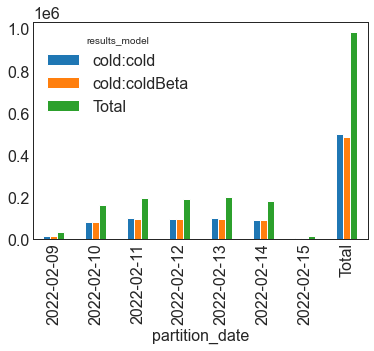

In [79]:
data_crosstab.plot(kind='bar')

In [80]:
# significance level
alpha = 0.05

# Calcualtion of Chisquare test statistics
chi_square = 0
rows = assignment['partition_date'].unique()
print(rows)
columns = assignment['results_model'].unique()
print(columns)

['2022-02-09' '2022-02-10' '2022-02-11' '2022-02-12' '2022-02-13'
 '2022-02-14' '2022-02-15']
['cold:cold' 'cold:coldBeta']


In [81]:
for i in columns:
    for j in rows:
        O = data_crosstab[i][j]
        E = data_crosstab[i]['Total'] * data_crosstab['Total'][j] / data_crosstab['Total']['Total']
        chi_square += (O-E)**2/E

In [82]:
# The p-value approach
print("Approach 1: The p-value approach to hypothesis testing in the decision rule")
p_value = 1 - stats.norm.cdf(chi_square, (len(rows)-1)*(len(columns)-1))
conclusion = "Failed to reject the null hypothesis."
if p_value <= alpha:
    conclusion = "Null Hypothesis is rejected."
        
print("chisquare-score is:", chi_square, " and p value is:", p_value)
print(conclusion)

Approach 1: The p-value approach to hypothesis testing in the decision rule
chisquare-score is: 39.34965181210874  and p value is: 0.0
Null Hypothesis is rejected.


In [ ]:
viewer_network      object
broadcast_id        object
view_start_time     object
viewer_gender       object
viewer_country      object
view_source         object
view_end_time       object
assignment          object